   student_id  age  gender school_type parent_education  study_hours  \
0           1   14    male      public    post graduate          3.1   
1           2   18  female      public         graduate          3.7   
2           3   17  female     private    post graduate          7.9   
3           4   16   other      public      high school          1.1   
4           5   16  female      public      high school          1.3   

   attendance_percentage internet_access travel_time extra_activities  \
0                   84.3             yes     <15 min              yes   
1                   87.8             yes     >60 min               no   
2                   65.5              no     <15 min               no   
3                   58.1              no   15-30 min               no   
4                   61.0             yes   30-60 min              yes   

  study_method  math_score  science_score  english_score  overall_score  \
0        notes        42.7           55.4           5

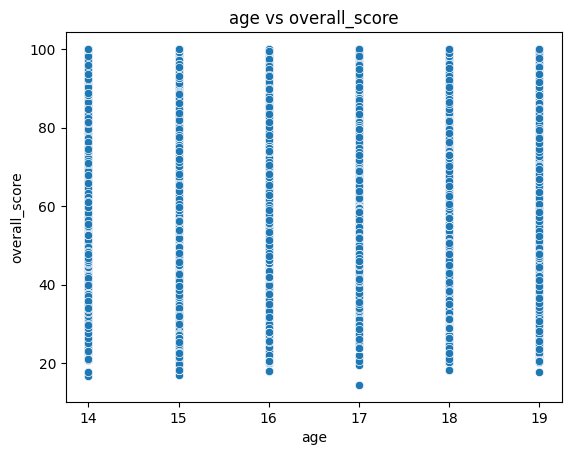

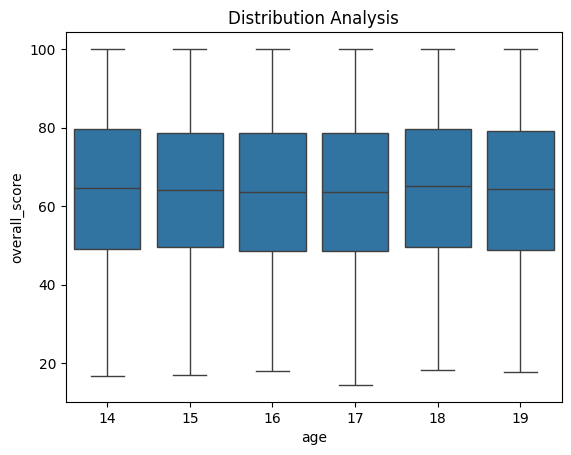

Linear Regression R2 Score: 0.952978054123655
Random Forest R2 Score: 0.9719298761599456


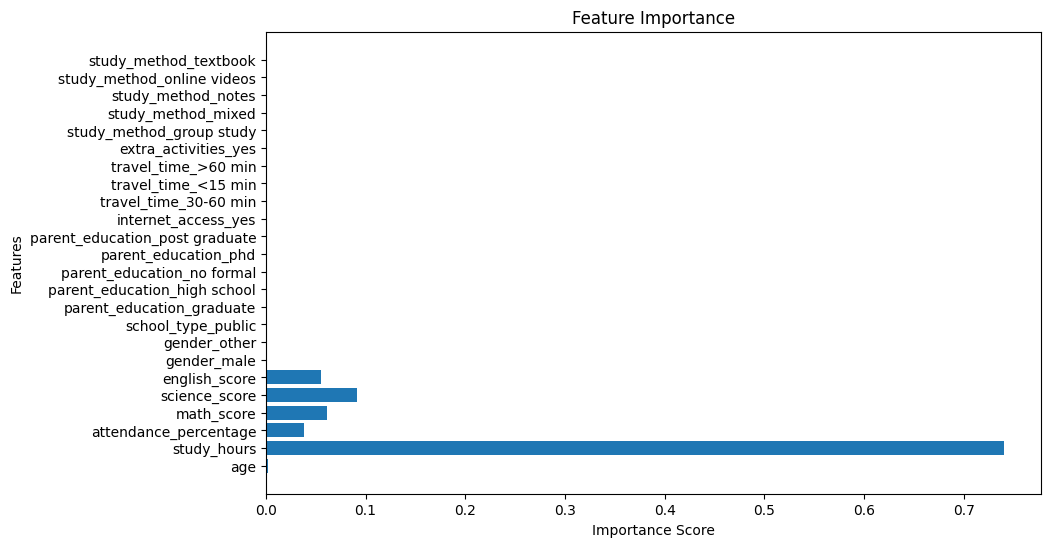


Enter values for prediction:
Enter value for age: 18
Enter value for study_hours: 5
Enter value for attendance_percentage: 80
Enter value for math_score: 70
Enter value for science_score: 72
Enter value for english_score: 75
Enter value for gender_male: 1
Enter value for gender_other: 0
Enter value for school_type_public: 1
Enter value for parent_education_graduate: 1
Enter value for parent_education_high school: 0
Enter value for parent_education_no formal: 0
Enter value for parent_education_phd: 0
Enter value for parent_education_post graduate: 0
Enter value for internet_access_yes: 1
Enter value for travel_time_30-60 min: 1
Enter value for travel_time_<15 min: 0
Enter value for travel_time_>60 min: 0
Enter value for extra_activities_yes: 1
Enter value for study_method_group study: 1
Enter value for study_method_mixed: 0
Enter value for study_method_notes: 0
Enter value for study_method_online videos: 0
Enter value for study_method_textbook: 0

Predicted Overall Score: 72.44


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Student_Performance.csv")

print(df.head())
df = df.dropna()
if 'student_id' in df.columns:
    df = df.drop('student_id', axis=1)
if 'final_grade' in df.columns:
    df = df.drop('final_grade', axis=1)

print("Columns after cleaning:", df.columns)
target_col = 'overall_score'
if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].astype('category').cat.codes
X = df.drop(target_col, axis=1)
y = df[target_col]
X = pd.get_dummies(X, drop_first=True)
feature_col = X.columns[0]

sns.scatterplot(x=X[feature_col], y=y)
plt.title(f"{feature_col} vs {target_col}")
plt.show()

sns.boxplot(x=X[feature_col], y=y)
plt.title("Distribution Analysis")
plt.show()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))
importance = rf_model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

print("\nEnter values for prediction:")

sample = X.iloc[0].copy()

for col in X.columns:
    val = float(input(f"Enter value for {col}: "))
    sample[col] = val
prediction = rf_model.predict([sample.values])

print("\nPredicted Overall Score:", round(prediction[0], 2))